In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import pingouin as pg
import numpy as np

**Loading of data**


In [3]:
# Replace with our file path
df = pd.read_csv("Output_extraction/ai_grading_final_v3.csv")

# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
print(df["ai_estimated_mistakes"])
# Dependent variable: AI grading error
df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])
df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

0       15
1       15
2       15
3       15
4       15
        ..
7989     0
7990     0
7991     0
7992     0
7993     0
Name: ai_estimated_mistakes, Length: 7994, dtype: int64


**2-way Mixed ANOVA**

Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 


ANOVA SUMMARY

Source              SS    DF1    DF2      MS       F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  -------  -----  -----  ------  ------  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes  703.310     15   1107  46.887  35.334    0.000      nan      0.324  nan           nan        nan        nan
prompt_type     19.707      4   4428   4.927   9.861    0.000        0.000  0.009    0.858         0.000      0.738      0.000
Interaction     52.069     60   4428   0.868   1.737    0.000      nan      0.023  nan           nan        nan        nan



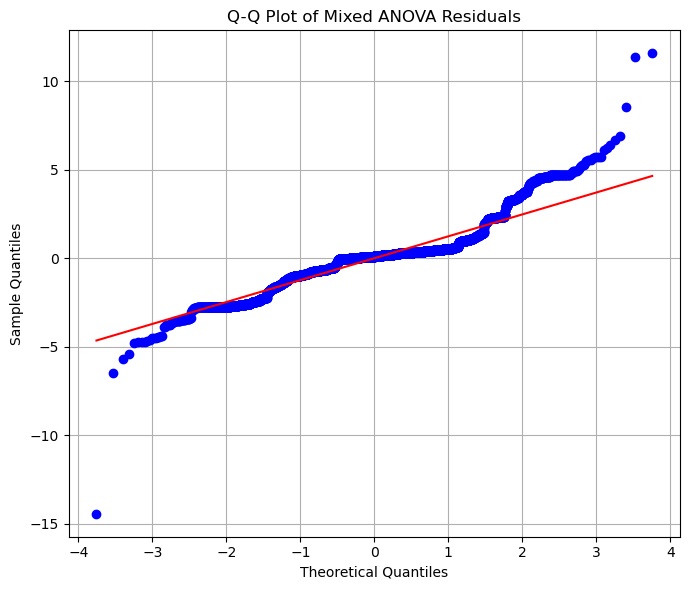

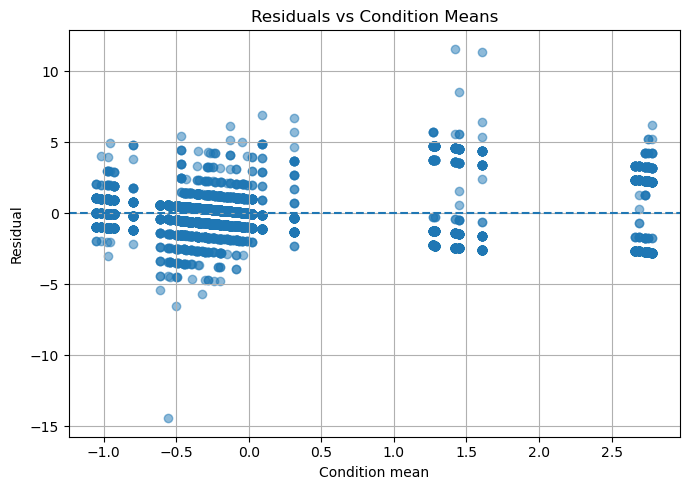

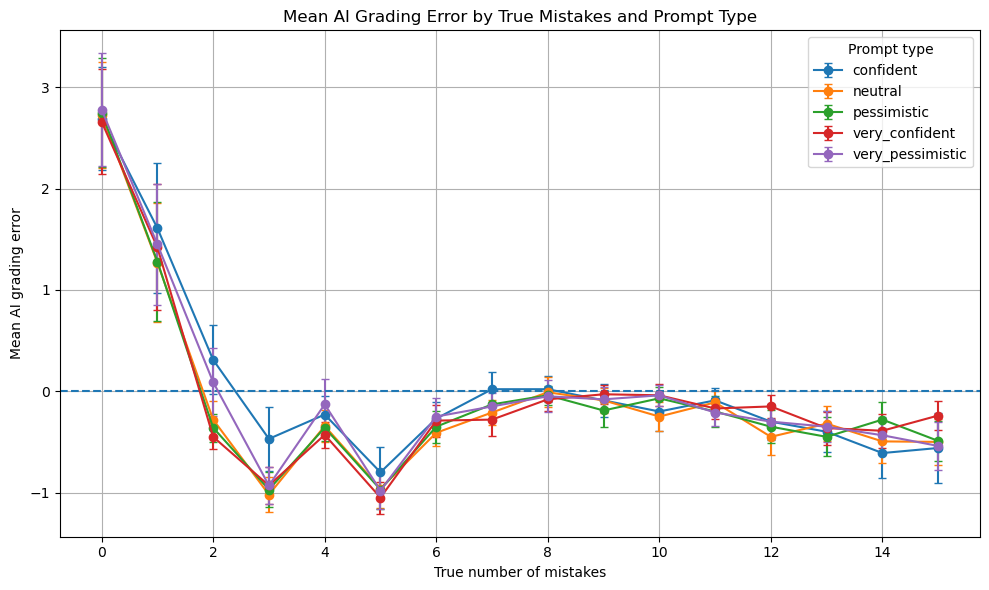

In [4]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error"].transform("mean")

df["anova_residual"] = df["ai_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means
#How far is this specific observation from the average result in the same condition? 
# One specific combination of true error level and prompt type.
#Condition means is the average value for each experimental condition.

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/17/zk5rsh150_n2c24m6gzdvb7m0000gn/T/ipykernel_10885/2159309426.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matrix_bc = df.groupby(["true_mistakes", "prompt_type"])["ai_error_boxcox"].apply(np.array).unstack("prompt_type")


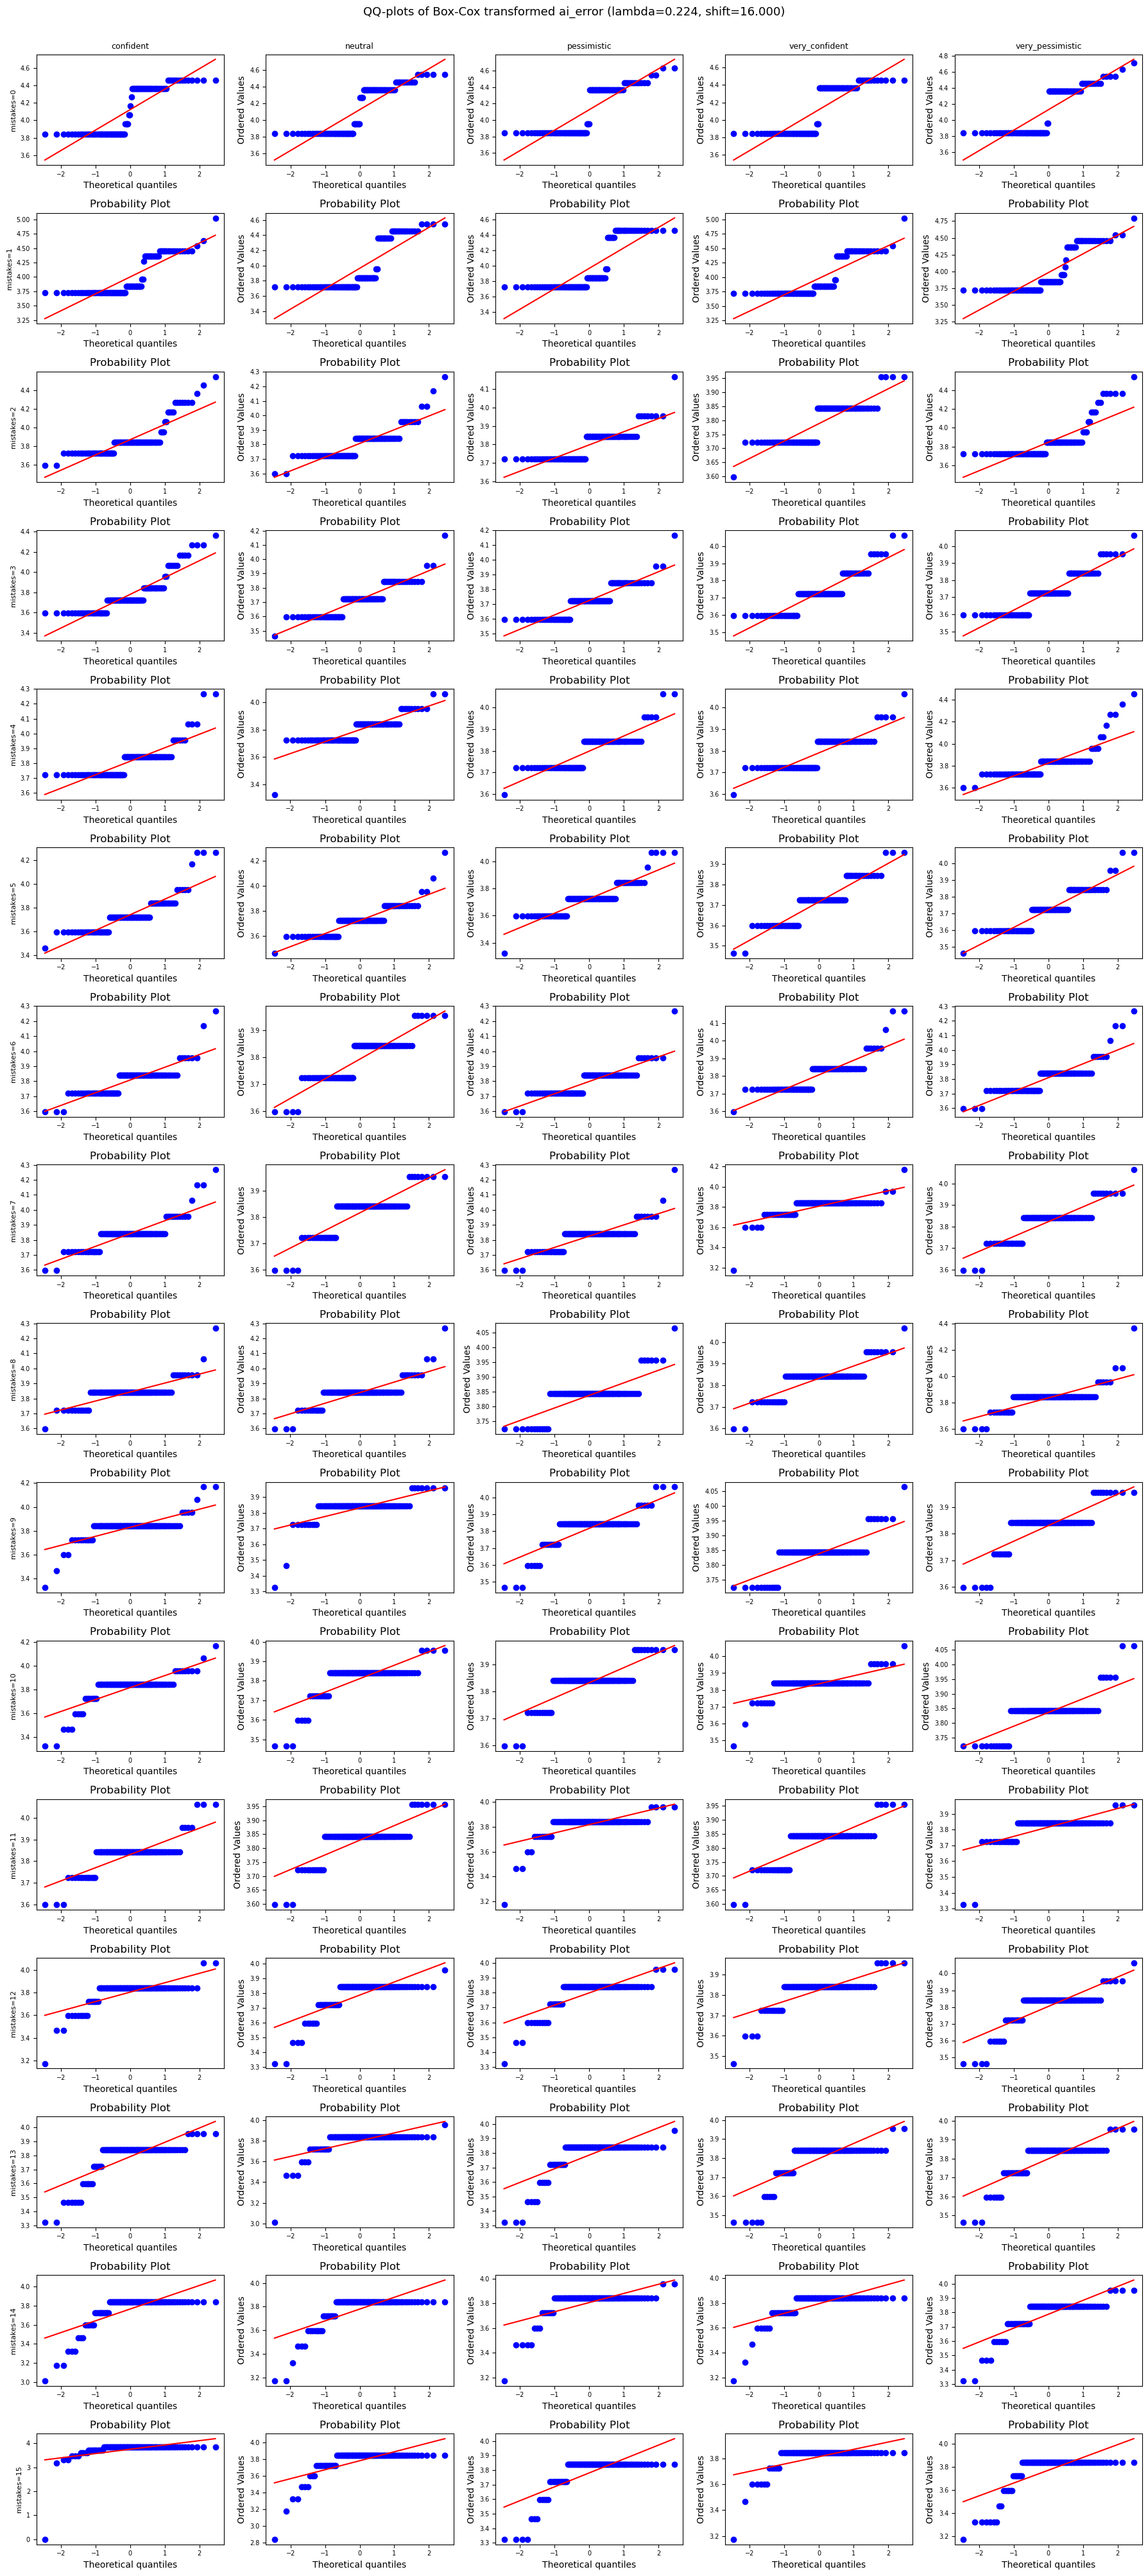

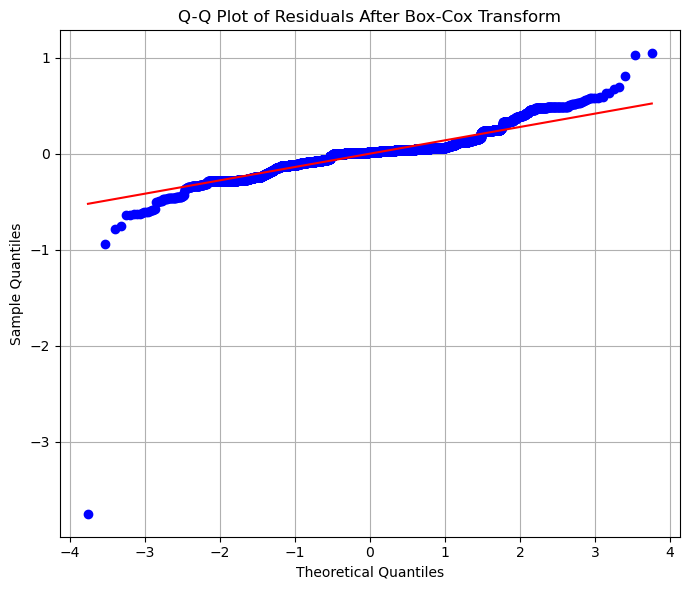

Box-Cox lambda: 0.223757
Global shift applied before Box-Cox: 16.000000


In [5]:
# qq plot matrix on Box-Cox transformed data
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Box-Cox must be applied to the response variable first.
# Since ai_error can be negative, shift it once globally before transforming.
raw = df["ai_error"].astype(float).to_numpy()
shift = 0.0
if raw.min() <= 0:
    shift = -raw.min() + 1

ai_error_bc, boxcox_lambda = stats.boxcox(raw + shift)
df["ai_error_boxcox"] = ai_error_bc

# Residuals are computed after the transformation.
df["cell_mean_boxcox"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error_boxcox"].transform("mean")
df["anova_residual_boxcox"] = df["ai_error_boxcox"] - df["cell_mean_boxcox"]

# Build the matrix from the transformed response.
matrix_bc = df.groupby(["true_mistakes", "prompt_type"])["ai_error_boxcox"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix_bc.index.tolist()  # expected 16 true_mistakes levels

fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix_bc.columns:
            ax.set_visible(False)
            continue

        vals = matrix_bc.loc[tm, prompt]
        if not isinstance(vals, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        vals = np.asarray(vals).ravel()
        if vals.size < 3:
            ax.set_visible(False)
            continue

        stats.probplot(vals, dist="norm", plot=ax)

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle(f"QQ-plots of Box-Cox transformed ai_error (lambda={boxcox_lambda:.3f}, shift={shift:.3f})", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual_boxcox"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals After Box-Cox Transform")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Box-Cox lambda: {boxcox_lambda:.6f}")
print(f"Global shift applied before Box-Cox: {shift:.6f}")

In [6]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="ai_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T     dof alternative     p_unc    p_corr p_adjust      BF10  \
0  4.623592  1122.0   two-sided  0.000004  0.000042     holm  1297.085   
1  4.178859  1122.0   two-sided  0.000032  0.000284     hol

**ABSOLUTE ERROR VERSION**


ANOVA SUMMARY

Source              SS    DF1    DF2      MS       F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  -------  -----  -----  ------  ------  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes  749.226     15   1107  49.948  55.326    0.000      nan      0.428  nan           nan        nan        nan
prompt_type      7.700      4   4428   1.925   5.149    0.000        0.001  0.005    0.935         0.000      0.870      0.000
Interaction     23.706     60   4428   0.395   1.057    0.358      nan      0.014  nan           nan        nan        nan



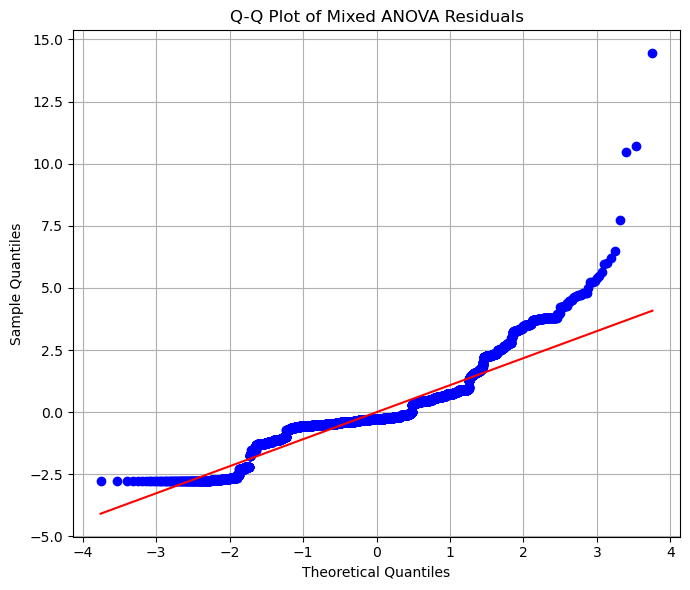

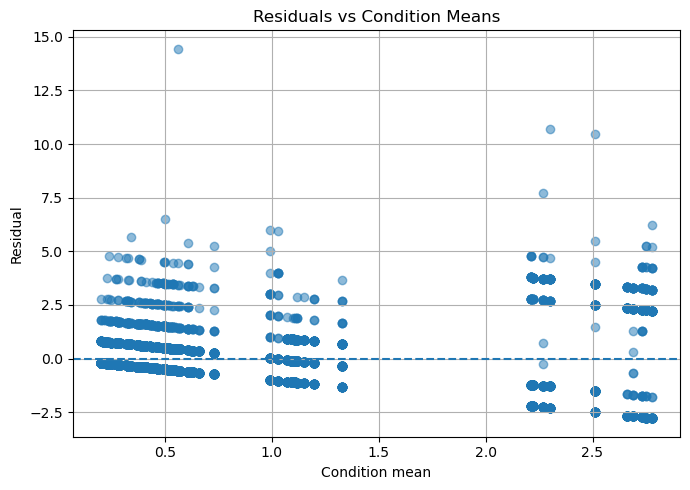

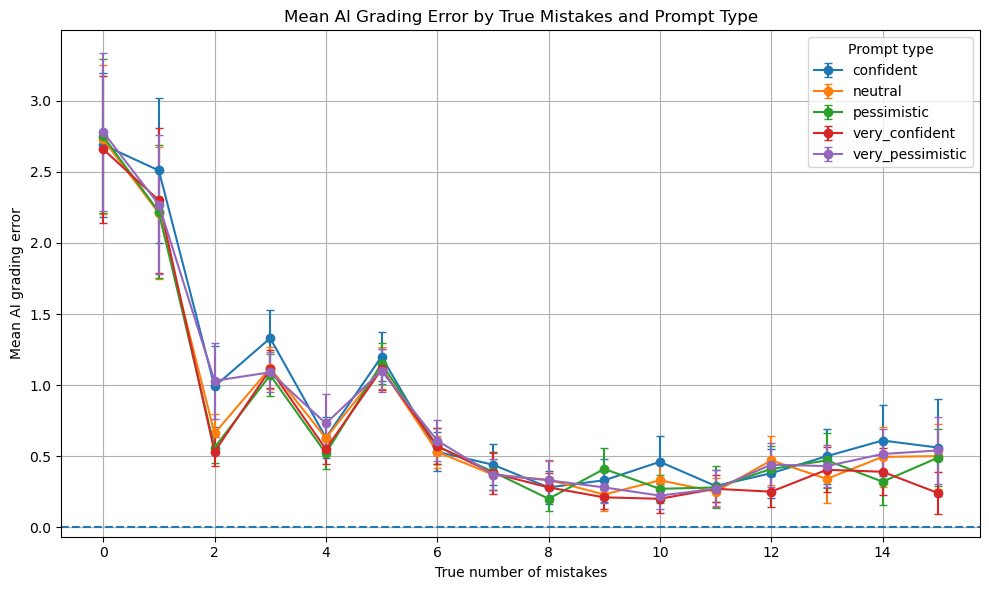

In [7]:
import pingouin as pg

mixed_anova = pg.mixed_anova(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["Absolute_error"].transform("mean")

df["anova_residual"] = df["Absolute_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T     dof alternative     p_unc    p_corr p_adjust     BF10  \
0  2.213307  1122.0   two-sided  0.027077  0.189540     holm    0.385   
1  2.825672  1122.0   two-sided  0.004802  0.038917     holm 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Output_extraction/ai_grading_final_v3.csv")

# Clean columns
df["answer_key_id"] = df["answer_key_id"].astype(str).str.strip()
df["prompt_type"] = df["prompt_type"].astype(str).str.strip()

# Create variables
df["grading_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["absolute_error"] = df["grading_error"].abs()
df["correct_estimate"] = (
    df["ai_estimated_mistakes"] == df["true_mistakes"]
).astype(int)

# Prompt order
prompt_order = [
    "very_pessimistic",
    "pessimistic",
    "neutral",
    "confident",
    "very_confident"
]

prompt_labels = [
    "Very pessimistic",
    "Pessimistic",
    "Neutral",
    "Confident",
    "Very confident"
]

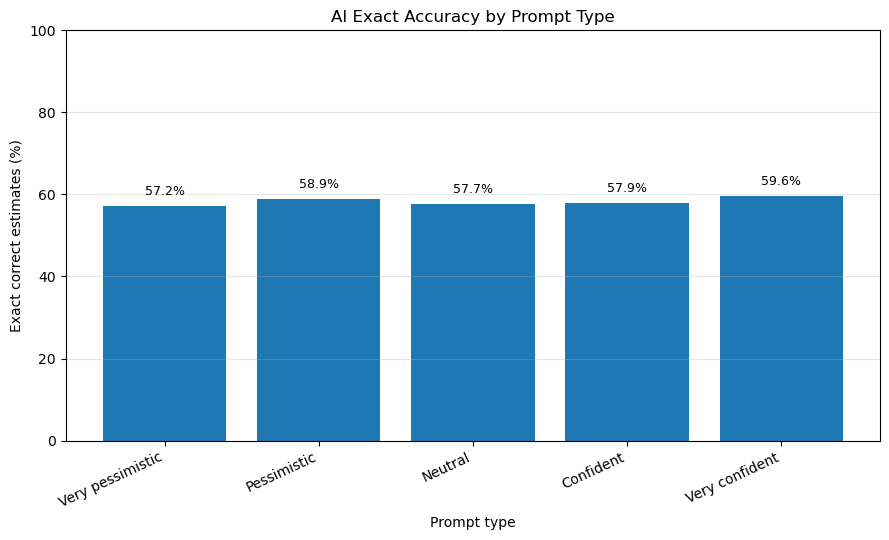

In [15]:
# Summarise exact accuracy by prompt type
summary_acc = (
    df.groupby("prompt_type")
      .agg(
          accuracy=("correct_estimate", "mean"),
          n=("correct_estimate", "size")
      )
      .reindex(prompt_order)
      .reset_index()
)

# Plot
plt.figure(figsize=(9, 5.5))

x = np.arange(len(summary_acc))

plt.bar(
    x,
    summary_acc["accuracy"] * 100
)

plt.xticks(x, prompt_labels, rotation=25, ha="right")
plt.ylabel("Exact correct estimates (%)")
plt.xlabel("Prompt type")
plt.title("AI Exact Accuracy by Prompt Type")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

# Add percentages above bars
for i, value in enumerate(summary_acc["accuracy"] * 100):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("ai_exact_accuracy_by_prompt.png", dpi=300, bbox_inches="tight")
plt.show()

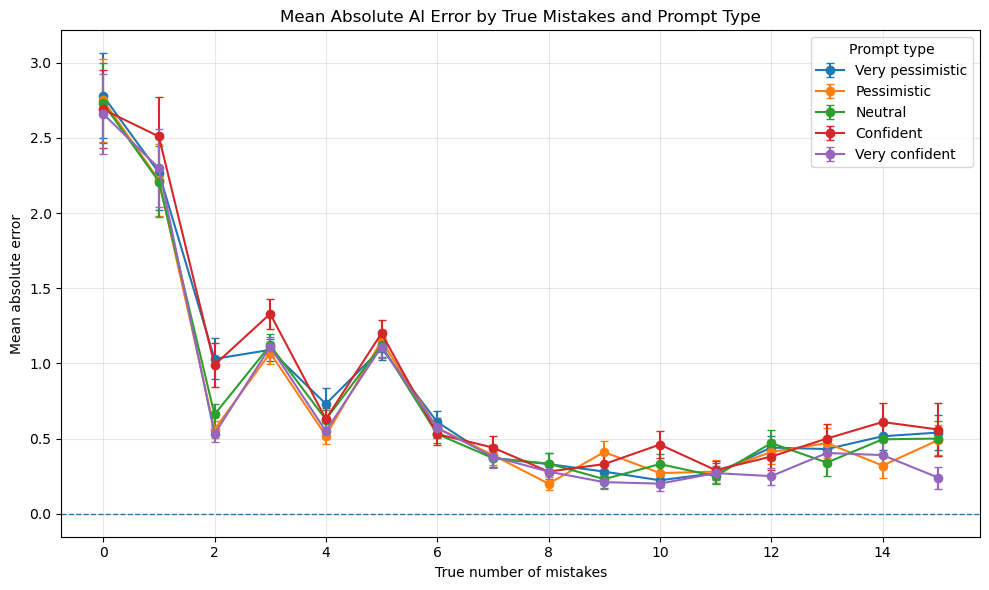

In [16]:
# Summarise absolute error by true mistakes and prompt type
summary_abs = (
    df.groupby(["true_mistakes", "prompt_type"])
      .agg(
          mean_absolute_error=("absolute_error", "mean"),
          sem=("absolute_error", "sem")
      )
      .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))

for prompt, label in zip(prompt_order, prompt_labels):
    sub = summary_abs[
        summary_abs["prompt_type"] == prompt
    ].sort_values("true_mistakes")

    plt.errorbar(
        sub["true_mistakes"],
        sub["mean_absolute_error"],
        yerr=sub["sem"],
        marker="o",
        capsize=3,
        label=label
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("True number of mistakes")
plt.ylabel("Mean absolute error")
plt.title("Mean Absolute AI Error by True Mistakes and Prompt Type")
plt.legend(title="Prompt type", frameon=True)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ai_mean_absolute_error_by_prompt.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
import pandas as pd
from scipy.stats import friedmanchisquare
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Load data
df = pd.read_csv("Output_extraction/ai_grading_final_v3.csv")

# Clean columns
df["answer_key_id"] = df["answer_key_id"].astype(str).str.strip()
df["prompt_type"] = df["prompt_type"].astype(str).str.strip()

# Create outcome variable
df["absolute_error"] = abs(
    df["ai_estimated_mistakes"] - df["true_mistakes"]
)

# Prompt order
prompt_order = [
    "very_pessimistic",
    "pessimistic",
    "neutral",
    "confident",
    "very_confident"
]

# If answer_key_id is not unique, create a repetition index
df["rep"] = df.groupby(
    ["answer_key_id", "true_mistakes", "prompt_type"]
).cumcount()

# Convert to wide format
df_wide = df.pivot_table(
    index=["answer_key_id", "true_mistakes", "rep"],
    columns="prompt_type",
    values="absolute_error",
    aggfunc="first"
)

# Keep only complete rows with all five prompt types
df_wide = df_wide[prompt_order].dropna()

# Friedman test
friedman_result = friedmanchisquare(
    df_wide["very_pessimistic"],
    df_wide["pessimistic"],
    df_wide["neutral"],
    df_wide["confident"],
    df_wide["very_confident"]
)

print("Friedman test")
print("Statistic:", friedman_result.statistic)
print("p-value:", friedman_result.pvalue)

Friedman test
Statistic: 10.559709733388633
p-value: 0.03198436795704993


In [22]:
posthoc_results = []

for p1, p2 in combinations(prompt_order, 2):
    test = wilcoxon(
        df_wide[p1],
        df_wide[p2],
        zero_method="wilcox",
        alternative="two-sided"
    )

    posthoc_results.append({
        "comparison": f"{p1} vs {p2}",
        "p_value": test.pvalue
    })

posthoc_df = pd.DataFrame(posthoc_results)

# Holm correction
posthoc_df["p_holm"] = multipletests(
    posthoc_df["p_value"],
    method="holm"
)[1]

print(posthoc_df)

                           comparison       p_value    p_holm
0     very_pessimistic vs pessimistic  1.068941e-01  0.427576
1         very_pessimistic vs neutral  1.780116e-01  0.534035
2       very_pessimistic vs confident  1.897123e-01  0.534035
3  very_pessimistic vs very_confident  2.645542e-04  0.002381
4              pessimistic vs neutral  8.016568e-01  0.801657
5            pessimistic vs confident  4.917920e-03  0.039343
6       pessimistic vs very_confident  3.891864e-02  0.194593
7                neutral vs confident  8.301377e-03  0.058110
8           neutral vs very_confident  8.310235e-03  0.058110
9         confident vs very_confident  7.509195e-07  0.000008
